# 传感器融合中的迭代最小二乘法

In [1]:
# 格式化书籍样式
from __future__ import division, print_function
%matplotlib inline
import sys
sys.path.insert(0, '..');
sys.path.insert(0, '../kf_book')
import book_format
book_format.set_style()

卡尔曼滤波器的一个重要应用类别是*传感器融合*。例如，我们可能有一个位置传感器和一个速度传感器，我们希望将两者的数据结合起来，找到状态的最优估计。在本节中，我们将讨论一种不同的情况：有多个传感器提供同一种类型的测量。

全球定位系统（GPS）的设计保证了在全球任何地点的任何时刻，至少有6颗卫星在视野范围内。GPS接收机知道每颗卫星相对于地球在天空中的位置。在每个历元（时间瞬间），接收机从每颗卫星接收信号，并据此推导出到该卫星的*伪距*。更详细地说，GPS接收机接收一个信号，该信号包含卫星标识以及信号发射的时间戳。GPS卫星上装有原子钟，因此时间戳极其精确。信号以光速传播，光速在真空中是恒定的，因此理论上GPS应该能够通过测量信号到达接收机所需的时间，产生极其精确的距离测量。但这里存在几个问题。首先，信号并不是在真空中传播，而是在大气层中传播。大气层会导致信号弯曲，因此信号并非沿直线传播，这使得信号到达接收机的时间比理论预期更长。其次，GPS*接收机*上的机载时钟精度不高，因此推导精确的时间间隔并非易事。第三，在许多环境中，信号会从建筑物、树木和其他物体上反射，导致路径变长或产生*多径效应*——在这种情况下，接收机同时接收到来自太空的原始信号和反射信号。

让我们用图形来理解这个问题。我将用二维图形来表示，以便于绘图和观察，当然这可以推广到三维。我们知道每颗卫星的位置以及到每颗卫星的距离（这个距离称为*伪距*；我们稍后将讨论原因）。我们无法精确测量距离，因此测量中存在噪声，我用线条的粗细来表示。下面是来自四颗卫星的四个伪距读数的示例。我将它们放置在一种不太可能出现的GPS星座配置中，仅仅是为了让交点更容易可视化。此外，所示的误差大小与距离不成比例，这也是为了更清楚地看到结果。

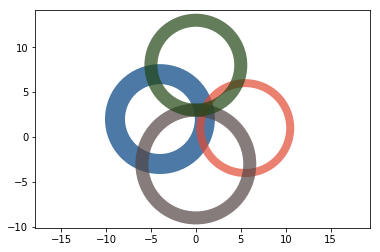

In [2]:
import ukf_internal
ukf_internal.show_four_gps()

在二维中，两个测量有时足以确定唯一解。距离圆有两个交点，但通常第二个交点在物理上不可行（它在太空或地下）。然而，对于GPS，我们还需要求解时间，因此需要第三个测量才能得到二维位置。

然而，由于GPS是一个三维系统，我们需要求解空间的3个维度和时间的1个维度。这是4个未知数，因此理论上用4颗卫星就拥有了所需的全部信息。然而，我们通常至少能观测到6颗卫星，而且往往更多。这意味着该系统是*超定*的。最后，由于测量中的噪声，没有哪个伪距的交点是完全精确的。

如果你精通线性代数，你会知道这是科学计算中一个极其常见的问题，并且有各种求解超定系统的技术。GPS接收机用来确定位置的最常用方法可能是*迭代最小二乘*算法，通常简写为ILS。正如你所知，如果误差服从高斯分布，那么最小二乘算法能找到最优解。换句话说，我们希望最小化超定系统中残差的平方。

让我们从一些你应该熟悉的定义开始。首先，我们将新息定义为

$$\delta \mathbf{\bar{z}}= \mathbf z - h(\mathbf{\bar{x}})$$

其中 $\mathbf z$ 是测量值，$h(\bullet)$ 是测量函数，$\delta \mathbf{\bar{z}}$ 是新息，在 FilterPy 中我们将其简写为 $y$。换句话说，这就是线性卡尔曼滤波器更新步骤中的方程 $\mathbf{y} = \mathbf z - \mathbf{H\bar{x}}$。

接下来，*测量残差*是

$$\delta \mathbf z^+ = \mathbf z - h(\mathbf x^+)$$

我不太使用上标加号，因为我觉得它很快会使方程变得难以阅读，但 $\mathbf x^+$ 是*后验*状态估计，即预测的或未知的未来状态。换句话说，线性卡尔曼滤波器的预测步骤计算的就是这个值。在这里，它代表ILS算法在每次迭代中将要计算的 $x$ 值。

这些方程给出了以下线性代数方程：

$$\delta \mathbf z^- = \mathbf H\delta \mathbf x + \delta \mathbf z^+$$

$\mathbf H$ 是我们的测量函数，定义为

$$\mathbf H = \frac{d\mathbf H}{d\mathbf x} = \frac{d\mathbf z}{d\mathbf x}$$

我们通过求导并令其为零来找到方程的最小值。在这种情况下，我们希望最小化残差的平方，因此我们的方程是

$$ \frac{\partial}{\partial \mathbf x}({\delta \mathbf z^+}^\mathsf{T}\delta \mathbf z^+) = 0,$$

其中

$$\delta \mathbf z^+=\delta \mathbf z^- - \mathbf H\delta \mathbf x.$$

这里我改用矩阵 $\mathbf H$ 作为测量函数。我们希望利用线性代数来执行ILS，因此在每一步中都需要计算矩阵 $\mathbf H$，它对应于每次迭代中的 $h(\mathbf{x^-})$。对于这类问题，$h(\bullet)$ 通常是非线性的，所以你需要在每一步对其进行线性化（稍后详述）。

出于各种原因，你可能希望对某些测量赋予更大的权重。例如，问题的几何形状可能有利于正交测量，或者某些测量可能比其他测量噪声更大。我们可以通过以下方程实现：

$$ \frac{\partial}{\partial \mathbf x}({\delta \mathbf z^+}^\mathsf{T}\mathbf{W}\delta \mathbf z^+) = 0$$

如果我们对第一个方程求解 ${\delta \mathbf x}$（推导过程见下一节），可以得到

$${\delta \mathbf x} = {{(\mathbf H^\mathsf{T}\mathbf H)^{-1}}\mathbf H^\mathsf{T} \delta \mathbf z^-}
$$

第二个方程则得到

$${\delta \mathbf x} = {{(\mathbf H^\mathsf{T}\mathbf{WH})^{-1}}\mathbf H^\mathsf{T}\mathbf{W} \delta \mathbf z^-}
$$

由于方程是超定的，我们无法精确求解这些方程，因此采用迭代方法。首先对位置做出初始猜测，然后利用这个猜测通过上述方程计算 ${\delta \mathbf x}$。将 ${\delta \mathbf x}$ 加到初始猜测上，再将新的状态反馈到方程中以产生另一个 ${\delta \mathbf x}$。我们以这种方式迭代，直到测量残差的变化足够小。

### ILS方程的推导

我将在代码中实现ILS，但首先让我们推导 $\delta \mathbf x$ 的方程。你可以跳过这个推导，但它具有一定的启发性，而且如果你了解基本的线性代数和偏微分方程，推导过程并不太难。

将 $\delta \mathbf z^+=\delta \mathbf z^- - \mathbf H\delta \mathbf x$ 代入偏微分方程，我们得到

$$ \frac{\partial}{\partial \mathbf x}(\delta \mathbf z^- -\mathbf H \delta \mathbf x)^\mathsf{T}(\delta \mathbf z^- - \mathbf H \delta \mathbf x)=0$$

展开后为

$$ \frac{\partial}{\partial \mathbf x}({\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\mathbf H\delta \mathbf x - 
{\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\delta \mathbf z^- - 
{\delta \mathbf z^-}^\mathsf{T}\mathbf H\delta \mathbf x +
{\delta \mathbf z^-}^\mathsf{T}\delta \mathbf z^-)=0$$

我们知道

$$\frac{\partial \mathbf{A}^\mathsf{T}\mathbf B}{\partial \mathbf B} = \frac{\partial \mathbf B^\mathsf{T}\mathbf{A}}{\partial \mathbf B} = \mathbf{A}^\mathsf{T}$$

因此第三项可以计算为

$$\frac{\partial}{\partial \mathbf x}{\delta \mathbf z^-}^\mathsf{T}\mathbf H\delta \mathbf x = {\delta \mathbf z^-}^\mathsf{T}\mathbf H$$

第二项为

$$\frac{\partial}{\partial \mathbf x}{\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\delta \mathbf z^-={\delta \mathbf z^-}^\mathsf{T}\mathbf H$$

我们还知道
$$\frac{\partial \mathbf B^\mathsf{T}\mathbf{AB}}{\partial \mathbf B} = \mathbf B^\mathsf{T}(\mathbf{A} + \mathbf{A}^\mathsf{T})$$

因此第一项变为

$$
\begin{aligned}
\frac{\partial}{\partial \mathbf x}{\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\mathbf H\delta \mathbf x &= {\delta \mathbf x}^\mathsf{T}(\mathbf H^\mathsf{T}\mathbf H + {\mathbf H^\mathsf{T}\mathbf H}^\mathsf{T})\\
&= {\delta \mathbf x}^\mathsf{T}(\mathbf H^\mathsf{T}\mathbf H + \mathbf H^\mathsf{T}\mathbf H) \\
&= 2{\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\mathbf H
\end{aligned}$$

最后，第四项是

$$ \frac{\partial}{\partial \mathbf x}
{\delta \mathbf z^-}^\mathsf{T}\delta \mathbf z^-=0$$

将展开的偏微分方程中的各项替换回来，我们得到

$$
 2{\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\mathbf H -
 {\delta \mathbf z^-}^\mathsf{T}\mathbf H - {\delta \mathbf z^-}^\mathsf{T}\mathbf H
 =0
$$

$${\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\mathbf H -
 {\delta \mathbf z^-}^\mathsf{T}\mathbf H = 0$$
 
$${\delta \mathbf x}^\mathsf{T}\mathbf H^\mathsf{T}\mathbf H =
 {\delta \mathbf z^-}^\mathsf{T}\mathbf H$$

两边同乘 $(\mathbf H^\mathsf{T}\mathbf H)^{-1}$，得到

$${\delta \mathbf x}^\mathsf{T} =
{\delta \mathbf z^-}^\mathsf{T}\mathbf H(\mathbf H^\mathsf{T}\mathbf H)^{-1}$$

对两边取转置，得到

$$\begin{aligned}
{\delta \mathbf x} &= ({{\delta \mathbf z^-}^\mathsf{T}\mathbf H(\mathbf H^\mathsf{T}\mathbf H)^{-1}})^\mathsf{T} \\
&={{(\mathbf H^\mathsf{T}\mathbf H)^{-1}}^T\mathbf H^\mathsf{T} \delta \mathbf z^-} \\
&={{(\mathbf H^\mathsf{T}\mathbf H)^{-1}}\mathbf H^\mathsf{T} \delta \mathbf z^-}
\end{aligned}$$

出于各种原因，你可能希望对某些测量赋予更大的权重。我们可以通过以下方程实现：

$$ \frac{\partial}{\partial \mathbf x}({\delta \mathbf z}^\mathsf{T}\mathbf{W}\delta \mathbf z) = 0$$

在上述推导的基础上加入 $\mathbf{W}$ 项，可得

$${\delta \mathbf x} = {{(\mathbf H^\mathsf{T}\mathbf{WH})^{-1}}\mathbf H^\mathsf{T}\mathbf{W} \delta \mathbf z^-}
$$

### 实现迭代最小二乘

我们的目标是实现以下方程的迭代求解：
$${\delta \mathbf x} = {{(\mathbf H^\mathsf{T}\mathbf H)^{-1}}\mathbf H^\mathsf{T} \delta \mathbf z^-}
$$

首先，我们需要计算 $\mathbf H$，其中 $\mathbf H =  d\mathbf z/d\mathbf x$。为了保持示例简小，使结果更容易解释，我们将用二维来实现。因此对于 $n$ 颗卫星，$\mathbf H$ 展开为

$$\mathbf H = \begin{bmatrix}
\frac{\partial p_1}{\partial x_1} & \frac{\partial p_1}{\partial y_1} \\
\frac{\partial p_2}{\partial x_2} & \frac{\partial p_2}{\partial y_2} \\
\vdots & \vdots \\
\frac{\partial p_n}{\partial x_n} & \frac{\partial p_n}{\partial y_n}
\end{bmatrix}$$

我们将通过计算 $x$ 的偏导数来线性化 $\mathbf H$：

$$ \frac{estimated\_x\_position - satellite\_x\_position}{estimated\_range\_to\_satellite}$$

$y$ 的方程只需将 $x$ 替换为 $y$。

算法流程如下。

    def ILS:
        猜测位置
        while not converged:
            计算当前估计位置到各卫星的距离
            计算在估计位置处线性化的 H
            通过 (H^T H)'H^T dz 计算新的估计增量
            新估计 = 当前估计 + 估计增量
            检查是否收敛
            

In [3]:
import numpy as np
from numpy.linalg import norm, inv
from numpy.random import randn
from numpy import dot

np.random.seed(1234)
user_pos = np.array([800, 200])

sat_pos = np.asarray(
    [[0, 1000],
     [0, -1000],
     [500, 500]], dtype=float)

def satellite_range(pos, sat_pos):
    """ 计算位置 'pos' 与 sat_pos 中位置列表之间的距离"""

    N = len(sat_pos)
    rng = np.zeros(N)

    diff = np.asarray(pos) - sat_pos

    for i in range(N):
        rng[i] = norm(diff[i])

    return norm(diff, axis=1)


def hx_ils(pos, sat_pos, range_est):
    """ 计算测量函数
    pos : array_like 
        当前二维估计位置。例如 (23, 45)
        
    sat_pos : array_like of 2D positions
        每颗卫星的位置，例如 [(0,100), (100,0)]
        
    range_est : array_like of floats
        到每颗卫星的距离
    """
    
    N = len(sat_pos)
    H = np.zeros((N, 2))
    for j in range(N):
        H[j, 0] = (pos[0] - sat_pos[j, 0]) / range_est[j]
        H[j, 1] = (pos[1] - sat_pos[j, 1]) / range_est[j]
    return H


def lop_ils(zs, sat_pos, pos_est, hx, eps=1.e-6):
    """ 在已知发射器位置的情况下，
    迭代估计一组测量的解"""
    pos = np.array(pos_est)

    with book_format.numpy_precision(precision=4):
        converged = False
        for i in range(20):
            r_est = satellite_range(pos, sat_pos)
            print('迭代次数:', i+1)

            H = hx(pos, sat_pos, r_est)        
            Hinv = inv(dot(H.T, H)).dot(H.T)

            # 更新位置估计
            y = zs - r_est
            print('新息', y)

            Hy = np.dot(Hinv, y)
            pos = pos + Hy
            print('位置       {}

'.format(pos))

            if max(abs(Hy)) < eps:
                converged = True
                break

    return pos, converged

# 计算到每个传感器的距离
rz = satellite_range(user_pos, sat_pos)

pos, converted = lop_ils(rz, sat_pos, (900, 90), hx=hx_ils)
print('迭代求解结果: ', pos)

iteration: 1
innovation [-148.512    28.6789 -148.5361]
pos       [805.4175 205.2868]


iteration: 2
innovation [-0.1177 -7.4049 -0.1599]
pos       [800.04   199.9746]


iteration: 3
innovation [-0.0463 -0.001  -0.0463]
pos       [800. 200.]


iteration: 4
innovation [-0. -0. -0.]
pos       [800. 200.]


Iterated solution:  [800. 200.]


让我们来分析一下这个结果。第一次迭代本质上执行的是线性卡尔曼滤波器在更新步骤中进行的计算：

$$\begin{aligned}
\mathbf y &= \mathbf z - \mathbf{Hx}\\
\mathbf x &= \mathbf x + \mathbf{Ky}
\end{aligned}$$

其中卡尔曼增益等于一。你可以看到，尽管初始猜测非常不准确 (900, 90)，计算出的 $\mathbf x$ 值 (805.4, 205.3) 已经非常接近真实值 (800, 200)。然而，它并不完美。但经过三次迭代，ILS算法就能够找到精确的解。所以希望你能清楚地理解为什么我们使用ILS而不是用卡尔曼滤波器来做传感器融合——它能给出更好的结果。当然，我们是从一个非常不准确的猜测开始的；如果猜测更准确呢？

In [4]:
pos, converted = lop_ils(rz, sat_pos, (801, 201), hx=hx_ils)
print('迭代求解结果: ', pos)

iteration: 1
innovation [-0.0009 -1.3868 -0.0024]
pos       [800.0014 199.9991]


iteration: 2
innovation [-0.0016 -0.     -0.0016]
pos       [800. 200.]


iteration: 3
innovation [-0. -0. -0.]
pos       [800. 200.]


Iterated solution:  [800. 200.]


第一次迭代产生了更好的估计，但通过迭代仍然可以进一步改进。

我在测量中没有注入噪声，以测试和展示滤波器的理论性能。现在让我们看看注入噪声后的表现。

In [5]:
# 添加一些噪声
nrz = []
for z in rz:
    nrz.append(z + randn())
pos, converted = lop_ils(nrz, sat_pos, (601,198.3), hx=hx_ils)
print('迭代求解结果: ', pos)

iteration: 1
innovation [129.8823 100.461  107.5398]
pos       [831.4474 186.1222]


iteration: 2
innovation [-31.6446  -7.4837 -30.7861]
pos       [800.3284 198.8076]


iteration: 3
innovation [-0.6041 -0.3813  0.3569]
pos       [799.948  198.6026]


iteration: 4
innovation [-0.4803  0.0004  0.4802]
pos       [799.9476 198.6025]


iteration: 5
innovation [-0.4802  0.0007  0.4803]
pos       [799.9476 198.6025]


Iterated solution:  [799.948 198.602]


我们可以看到，噪声意味着我们不再能找到精确的解，但仍然能够快速收敛到一个比第一次迭代结果更准确的解。

以上远非对迭代最小二乘算法的完整介绍，更不用说GNSS中用于从GPS伪距计算位置的各种方法了。你将在文献中找到许多不同的方法，包括QR分解、SVD以及其他求解超定系统的技术。对于一个实际的任务，你需要查阅文献，并根据你的具体传感器配置、噪声水平、精度要求以及可承受的计算量来设计自己的算法。